In [1]:
from modules.dna_tokenizer import DNATokenizer

# Create tokenizer
tokenizer = DNATokenizer()

# Test
#seq = "ATC---GATCG"
#tokens = tokenizer(seq, return_tensors="pt")
#print(tokens)

/home/shishir-sunar/anaconda3/envs/insdel_glm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import json

from modules.bert_config import BertConfig

with open("config.json", "r") as f:
    config_dict = json.load(f)

config = BertConfig(**config_dict)

In [3]:
from modules.custom_bert import DNABertForMaskedLM

model = DNABertForMaskedLM(config)


In [4]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15  # fraction of nucleotides to mask
)

In [29]:
from torch.utils.data import Dataset
import pandas as pd
import torch 

class DNADataset(Dataset):
    def __init__(self, sequences, tokenizer, max_length=512):
        self.sequences = sequences
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        item = self.tokenizer(
                    self.sequences[idx],
                    padding="max_length",
                    #truncation=True,
                    max_length=self.max_length,
                    #return_special_tokens_mask=True,
                )
        return {k: v.squeeze(0) for k, v in item.items()}


data_df = pd.read_parquet("data/simulated/simulated_sequences.parquet")
train_sequences = data_df["sequences"].iloc[:4000].tolist()
val_sequences   = data_df["sequences"].iloc[4000:5000].tolist()

train_dataset = DNADataset(sequences=train_sequences, tokenizer=tokenizer)
eval_dataset = DNADataset(sequences=val_sequences, tokenizer=tokenizer)



In [30]:
sample = train_dataset[0]
print(sample["input_ids"].shape)


torch.Size([512])


In [ ]:
# Custom DataCollator that extends transformers' DataCollatorForLanguageModeling
from transformers import DataCollatorForLanguageModeling
import torch
import random

class CustomDataCollatorForMLM(DataCollatorForLanguageModeling):
    def torch_mask_tokens(self, inputs, special_tokens_mask=None, **kwargs):
        """
        Override the masking method to use our custom mask_sequence logic.
        """
        labels = inputs.clone()
        # We sample a few tokens in each sequence for MLM training 
        probability_matrix = torch.full(labels.shape, self.mlm_probability)
        
        if special_tokens_mask is None:
            special_tokens_mask = [
                self.tokenizer.get_special_tokens_mask(val, already_has_special_tokens=True) 
                for val in labels.tolist()
            ]
            special_tokens_mask = torch.tensor(special_tokens_mask, dtype=torch.bool)
        else:
            special_tokens_mask = special_tokens_mask.bool()

        probability_matrix.masked_fill_(special_tokens_mask, value=0.0)
        masked_indices = torch.bernoulli(probability_matrix).bool()
        labels[~masked_indices] = -100  # We only compute loss on masked tokens

        # Apply our custom masking logic (80/10/10 rule)
        for i in range(inputs.shape[0]):  # For each sequence in batch
            for j in range(inputs.shape[1]):  # For each token in sequence
                if masked_indices[i, j]:
                    prob = random.random()
                    if prob < 0.8:  # 80% of time: replace with [MASK]
                        inputs[i, j] = self.tokenizer.mask_token_id
                    elif prob < 0.9:  # 10% of time: replace with random DNA token
                        # Random DNA token (A, T, C, G are tokens 0, 1, 2, 3)
                        inputs[i, j] = random.choice([0, 1, 2, 3])
                    # 10% of time: keep original (no change needed)

        return inputs, labels

# Create the custom data collator
custom_data_collator = CustomDataCollatorForMLM(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15
)

# Training with validation every epoch
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    learning_rate=1e-4,
    report_to=None
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=custom_data_collator
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,1.442100,1.436817
2,1.433800,1.437212
3,1.425600,1.436310


TrainOutput(global_step=750, training_loss=1.4369950408935548, metrics={'train_runtime': 138.6143, 'train_samples_per_second': 86.571, 'train_steps_per_second': 5.411, 'total_flos': 177211772928000.0, 'train_loss': 1.4369950408935548, 'epoch': 3.0})

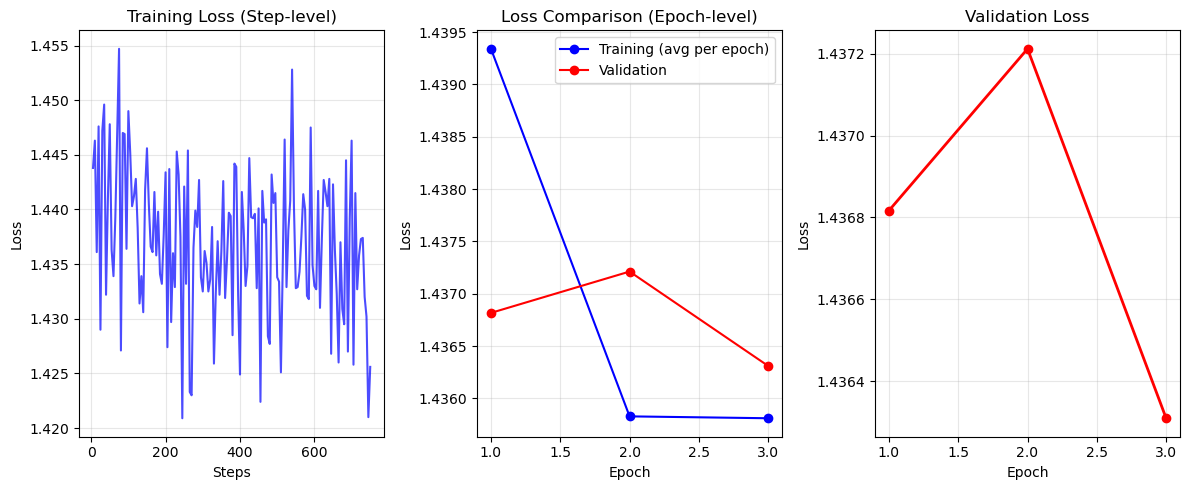

In [32]:
# Plot loss curves
import matplotlib.pyplot as plt
import numpy as np

logs = trainer.state.log_history
train_logs = [x for x in logs if 'loss' in x and 'eval_loss' not in x]
eval_logs = [x for x in logs if 'eval_loss' in x]

# Get step-level training loss
train_steps = [x['step'] for x in train_logs]
train_losses = [x['loss'] for x in train_logs]

# Get epoch-level validation loss
eval_epochs = [x['epoch'] for x in eval_logs]
eval_losses = [x['eval_loss'] for x in eval_logs]

# Calculate epoch-averaged training loss
epochs = list(range(1, int(max(eval_epochs)) + 1))
train_loss_per_epoch = []

for epoch in epochs:
    # Find training losses for this epoch
    epoch_start = (epoch - 1) * (len(train_dataset) // 16)  # steps per epoch
    epoch_end = epoch * (len(train_dataset) // 16)
    
    epoch_losses = [loss for step, loss in zip(train_steps, train_losses) 
                   if epoch_start < step <= epoch_end]
    
    if epoch_losses:
        train_loss_per_epoch.append(np.mean(epoch_losses))
    else:
        train_loss_per_epoch.append(None)

plt.figure(figsize=(12, 5))

# Plot 1: Step-level training loss
plt.subplot(1, 3, 1)
plt.plot(train_steps, train_losses, 'b-', alpha=0.7)
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss (Step-level)')
plt.grid(True, alpha=0.3)

# Plot 2: Epoch-level comparison
plt.subplot(1, 3, 2)
plt.plot(epochs, train_loss_per_epoch, 'bo-', label='Training (avg per epoch)')
plt.plot(eval_epochs, eval_losses, 'ro-', label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Comparison (Epoch-level)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Validation loss only
plt.subplot(1, 3, 3)
plt.plot(eval_epochs, eval_losses, 'ro-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()